一.lightgbm模型

In [1]:
import pandas as pd

df = pd.read_csv('D:/bishe_zoujun/test1/data_all/Data for repository.csv')
df.head()

df['Revenue(INR)'] = df['Revenue(INR)'] / 83.5
df['Budget(INR)'] = df['Budget(INR)'] / 83.5

df.rename(columns={'Revenue(INR)': 'gross'}, inplace=True)
df.rename(columns={'Budget(INR)': 'budget'}, inplace=True)
df.rename(columns={'Genre': 'genres'}, inplace=True)

df.head()

,Movie_Name,Release_Period,Whether_Remake,Whether_Franchise,genres,New_Actor,New_Director,New_Music_Director,Lead_Star,Director,Music_Director,Number_of_Screens,gross,budget
0,Golden Boys,Normal,No,No,suspense,Yes,No,No,Jeet Goswami,Ravi Varma,Baba Jagirdar,5,5.988024e+04,1017.964072
1,Kaccha Limboo,Holiday,No,No,drama,Yes,No,Yes,Karan Bhanushali,Sagar Ballary,Amardeep Nijjer,75,1.796407e+05,9880.239521
2,Not A Love Story,Holiday,No,No,thriller,No,No,No,Mahie Gill,Ram Gopal Verma,Sandeep Chowta,525,8.982036e+05,679041.916168
3,Qaidi Band,Holiday,No,No,drama,Yes,No,No,Aadar Jain,Habib Faisal,Amit Trivedi,800,2.514970e+06,53892.215569
4,Chaatwali,Holiday,No,No,adult,Yes,Yes,Yes,Aadil Khan,Aadil Khan,Babloo Ustad,1,1.197605e+04,12874.251497


Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 1.65768e+06	valid's rmse: 1.81662e+06
[200]	train's rmse: 1.37197e+06	valid's rmse: 1.50774e+06
[300]	train's rmse: 1.29318e+06	valid's rmse: 1.4423e+06
[400]	train's rmse: 1.25359e+06	valid's rmse: 1.42821e+06
Early stopping, best iteration is:
[400]	train's rmse: 1.25359e+06	valid's rmse: 1.42821e+06

优化后 RMSE: 1428210.48
训练集 R²: 0.8137
测试集 R²: 0.7671


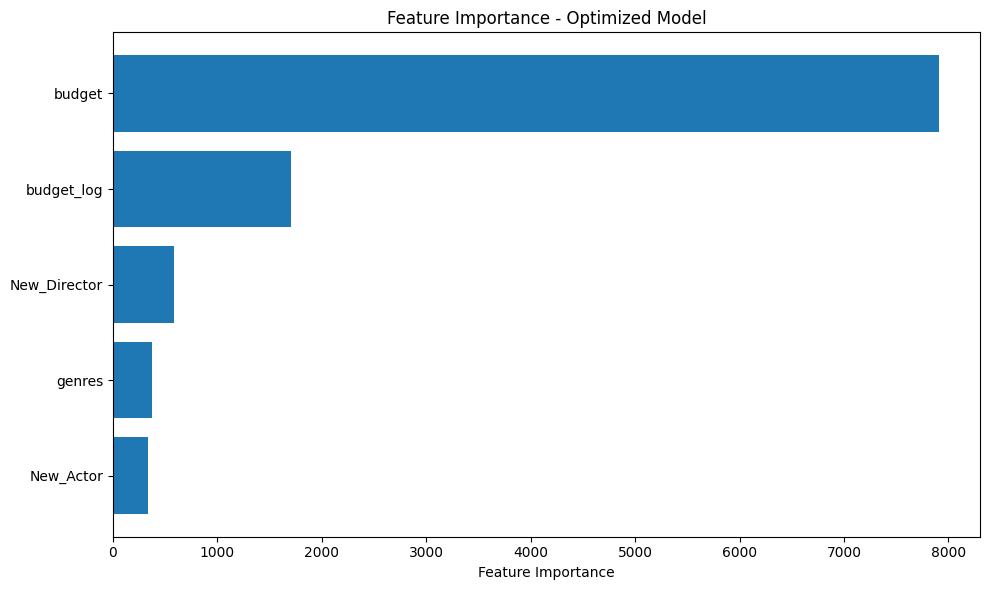

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

X = df[['genres','New_Director','New_Actor','budget']].copy()
y = df['gross'].copy()

X['budget_log'] = np.log1p(X['budget'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=cat_cols)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 50,
    'learning_rate': 0.01,
    'max_depth': 8,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n优化后 RMSE: {rmse:.2f}")

y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
print(f"训练集 R²: {train_r2:.4f}")
print(f"测试集 R²: {r2:.4f}")

importance = model.feature_importance()
feature_names = X_train.columns
sorted_idx = importance.argsort()

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Feature Importance - Optimized Model")
plt.tight_layout()
plt.show()